In [41]:
import numpy as np
import matplotlib.pyplot as plt
import verde as vd
import harmonica as hm
import boule as bl
import choclo

In [42]:
# def foward_modeling_spherical_coordinates(coordinates,
#                                           dipoles,
#                                           inclination,
#                                           declination,
#                                           magnetic_moments):
#     """
#     Computes the magnetic field components in spherical coordinates at observation points 
#     due to a set of dipoles, each with a specified magnetic moment.

#     Parameters:
#     - coordinates (tuple of arrays): A tuple containing the spherical coordinates (longitude, latitude, radius) 
#       of the observation points. Each coordinate should be a 1D array.
#     - dipoles (tuple of arrays): A tuple containing the spherical coordinates (longitude, latitude, radius) 
#       of the source dipoles. Each dipole's position is described by a 1D array for longitude, latitude, and radius.
#     - magnetic_moments (tuple of arrays): A tuple containing the magnetic moments of the dipoles, given by three 
#       components. Each component is a 1D array.

#     Returns:
#     - B_r (array): Magnetic field component in the radial direction (nT) at each observation point.
#     - B_theta (array): Magnetic field component in the theta direction (nT) at each observation point.
#     - B_phi (array): Magnetic field component in the phi direction (nT) at each observation point.

#     This function:
#     1. Converts latitude and longitude from degrees to radians for spherical coordinate calculations.
#     2. Calculates directional cosines and separation distances between source and observation points.
#     3. Computes intermediate matrices (H_ij) accounting for the geometry and separation between source and observation points.
#     4. Uses the magnetic moments and geometry to compute the magnetic field components in spherical coordinates.

#     Notes:
#     - The magnetic field components are returned in nanotesla (nT).
#     - The constant CM (not passed as an argument) is used to scale the magnetic field based on the source-observation geometry.

#     The function assumes that the magnetic field is modeled by the superposition of dipoles with specified magnetic moments. 
#     Each dipole is characterized by its position in spherical coordinates (longitude, latitude, radius) and its magnetic moment components.
#     """
#     coordinates = tuple(c.ravel() for c in coordinates)
#     dipoles = tuple(c.ravel() for c in dipoles)
#     magnetic_moments = tuple(c.ravel() for c in magnetic_moments)

#     longitude_obs = np.deg2rad(coordinates[0])
#     colatitude_obs = np.pi/2 - np.deg2rad(coordinates[1])
#     radius_observed_data = coordinates[2]

#     B_r = np.zeros(len(coordinates[0]))
#     B_phi = np.zeros(len(coordinates[0]))
#     B_theta = np.zeros(len(coordinates[0]))

#     # Calculate the directional cossines
#     for i in range(len(dipoles[0].ravel())):
#       longitude_source = np.deg2rad(dipoles[0][i])
#       colatitude_source = np.pi/2 - np.deg2rad(dipoles[1][i])
#       radius_source = dipoles[2][i]

#       m_jphi = np.cos(inclination) * np.cos(declination) * magnetic_moments[i][0]
#       m_jtheta = - np.cos(inclination) * np.cos(declination) * magnetic_moments[i][1]
#       m_jr = - np.sin(inclination) * magnetic_moments[i][2]

#       diff_long_obs_long_source = longitude_obs - longitude_source
#       mu_ij = np.cos(colatitude_obs) * np.cos(colatitude_source) + np.sin(colatitude_obs) * np.sin(colatitude_source) * np.cos(diff_long_obs_long_source)
#       ri_dot_thetaj = -np.cos(colatitude_obs) * np.sin(colatitude_source) + np.sin(colatitude_obs) * np.cos(colatitude_source) * np.cos(diff_long_obs_long_source)
#       ri_dot_phij = np.sin(colatitude_obs) * np.sin(diff_long_obs_long_source)
#       thetai_dot_rj = -np.sin(colatitude_obs) * np.cos(colatitude_source) + np.cos(colatitude_obs) * np.sin(colatitude_source) * np.cos(diff_long_obs_long_source)
#       thetai_dot_thetaj = np.sin(colatitude_obs) * np.sin(colatitude_source) + np.cos(colatitude_obs) * np.cos(colatitude_source) * np.cos(diff_long_obs_long_source)
#       thetai_dot_phij = np.cos(colatitude_obs) * np.sin(diff_long_obs_long_source)
#       phii_dot_rj = -np.sin(colatitude_source) * np.sin(diff_long_obs_long_source)
#       phii_dot_thetaj = -np.cos(colatitude_source) * np.sin(diff_long_obs_long_source)
#       phii_dot_phij = np.cos(diff_long_obs_long_source)
      
#       # Distance r_ij between points
#       r_ij = np.sqrt((radius_observed_data ** 2) + (radius_source ** 2) - 2 * radius_observed_data * radius_source * mu_ij)
      
#       # Define magnetic field terms
#       CONSTANT = CM / r_ij ** 3
#       H_11 = CONSTANT * (3 * ((radius_observed_data - radius_source * mu_ij) * (radius_observed_data * mu_ij - radius_source) / r_ij ** 2) - mu_ij)
#       H_12 = CONSTANT * (3 * ((radius_observed_data - radius_source * mu_ij) * (radius_observed_data * ri_dot_thetaj) / r_ij ** 2) - ri_dot_thetaj)
#       H_13 = CONSTANT * (3 * ((radius_observed_data - radius_source * mu_ij) * (radius_observed_data * ri_dot_phij) / r_ij ** 2) - ri_dot_phij)
#       H_21 = -CONSTANT * (3 * ((radius_source * thetai_dot_rj) * (radius_observed_data * mu_ij - radius_source) / r_ij ** 2) + thetai_dot_rj)
#       H_22 = -CONSTANT * (3 * ((radius_source * thetai_dot_rj) * (radius_observed_data * ri_dot_thetaj) / r_ij ** 2) + thetai_dot_thetaj)
#       H_23 = -CONSTANT * (3 * ((radius_source * thetai_dot_rj) * (radius_observed_data * ri_dot_phij) / r_ij ** 2) + thetai_dot_phij)
#       H_31 = -CONSTANT * (3 * ((radius_source * phii_dot_rj) * (radius_observed_data * mu_ij - radius_source) / r_ij ** 2) + phii_dot_rj)
#       H_32 = -CONSTANT * (3 * ((radius_source * phii_dot_rj) * (radius_observed_data * ri_dot_thetaj) / r_ij ** 2) + phii_dot_thetaj)
#       H_33 = -CONSTANT * (3 * ((radius_source * phii_dot_rj * radius_observed_data * ri_dot_phij) / r_ij ** 2) + phii_dot_phij)

#       # Calculate magnetic components for each field direction
#       mj_ri = m_jr * mu_ij + m_jtheta * ri_dot_thetaj + m_jphi * ri_dot_phij
#       mj_thetai = m_jr * thetai_dot_rj + m_jtheta * thetai_dot_thetaj + m_jphi * thetai_dot_phij
#       mj_phii = m_jr * phii_dot_rj + m_jtheta * phii_dot_thetaj + m_jphi * phii_dot_phij
#       # Calculate final magnetic field components

#       B_r += (H_11 * mj_ri + H_12 * mj_thetai + H_13 * mj_phii) * 1e9
#       B_theta += (H_21 * mj_ri + H_22 * mj_thetai + H_23 * mj_phii) * 1e9
#       B_phi += (H_31 * mj_ri + H_32 * mj_thetai + H_33 * mj_phii) * 1e9

#     return B_r, B_theta, B_phi

SyntaxError: invalid syntax (2424161052.py, line 49)

In [56]:
def foward_modeling_spherical(coordinates,
                                          dipoles,
                                          inclination,
                                          declination,
                                          magnetic_moments):
    """
    Computes the magnetic field components in spherical coordinates at observation points 
    due to a set of dipoles, each with a specified magnetic moment.

    Parameters:
    - coordinates (tuple of arrays): A tuple containing the spherical coordinates (longitude, latitude, radius) 
      of the observation points. Each coordinate should be a 1D array.
    - dipoles (tuple of arrays): A tuple containing the spherical coordinates (longitude, latitude, radius) 
      of the source dipoles. Each dipole's position is described by a 1D array for longitude, latitude, and radius.
    - magnetic_moments (tuple of arrays): A tuple containing the magnetic moments of the dipoles, given by three 
      components. Each component is a 1D array.

    Returns:
    - B_r (array): Magnetic field component in the radial direction (nT) at each observation point.
    - B_theta (array): Magnetic field component in the theta direction (nT) at each observation point.
    - B_phi (array): Magnetic field component in the phi direction (nT) at each observation point.

    This function:
    1. Converts latitude and longitude from degrees to radians for spherical coordinate calculations.
    2. Calculates directional cosines and separation distances between source and observation points.
    3. Computes intermediate matrices (H_ij) accounting for the geometry and separation between source and observation points.
    4. Uses the magnetic moments and geometry to compute the magnetic field components in spherical coordinates.

    Notes:
    - The magnetic field components are returned in nanotesla (nT).
    - The constant CM (not passed as an argument) is used to scale the magnetic field based on the source-observation geometry.

    The function assumes that the magnetic field is modeled by the superposition of dipoles with specified magnetic moments. 
    Each dipole is characterized by its position in spherical coordinates (longitude, latitude, radius) and its magnetic moment components.
    """
    coordinates = tuple(c.ravel() for c in coordinates)
    dipoles = tuple(c.ravel() for c in dipoles)
    magnetic_moments = tuple(c.ravel() for c in magnetic_moments)

    longitude_obs = np.deg2rad(coordinates[0])
    colatitude_obs = np.pi/2 - np.deg2rad(coordinates[1])
    radius_observed_data = coordinates[2]

    B_r = np.zeros(len(coordinates[0]))
    B_phi = np.zeros(len(coordinates[0]))
    B_theta = np.zeros(len(coordinates[0]))

    # Calculate the directional cossines
    n_dipoles= magnetic_moments[0].size
    for i in range(n_dipoles):
      longitude_source = np.deg2rad(dipoles[0][i])
      colatitude_source = np.pi/2 - np.deg2rad(dipoles[1][i])
      radius_source = dipoles[2][i]

      m_jphi = np.cos(inclination) * np.cos(declination) * magnetic_moments[0][i]
      m_jtheta = - np.cos(inclination) * np.cos(declination) * magnetic_moments[1][i]
      m_jr = - np.sin(inclination) * magnetic_moments[2][i]

      diff_long_obs_long_source = longitude_obs - longitude_source
      mu_ij = np.cos(colatitude_obs) * np.cos(colatitude_source) + np.sin(colatitude_obs) * np.sin(colatitude_source) * np.cos(diff_long_obs_long_source)
      ri_dot_thetaj = -np.cos(colatitude_obs) * np.sin(colatitude_source) + np.sin(colatitude_obs) * np.cos(colatitude_source) * np.cos(diff_long_obs_long_source)
      ri_dot_phij = np.sin(colatitude_obs) * np.sin(diff_long_obs_long_source)
      thetai_dot_rj = -np.sin(colatitude_obs) * np.cos(colatitude_source) + np.cos(colatitude_obs) * np.sin(colatitude_source) * np.cos(diff_long_obs_long_source)
      thetai_dot_thetaj = np.sin(colatitude_obs) * np.sin(colatitude_source) + np.cos(colatitude_obs) * np.cos(colatitude_source) * np.cos(diff_long_obs_long_source)
      thetai_dot_phij = np.cos(colatitude_obs) * np.sin(diff_long_obs_long_source)
      phii_dot_rj = -np.sin(colatitude_source) * np.sin(diff_long_obs_long_source)
      phii_dot_thetaj = -np.cos(colatitude_source) * np.sin(diff_long_obs_long_source)
      phii_dot_phij = np.cos(diff_long_obs_long_source)
      
      # Distance r_ij between points
      r_ij = np.sqrt((radius_observed_data ** 2) + (radius_source ** 2) - 2 * radius_observed_data * radius_source * mu_ij)
      
      # Define magnetic field terms
      CONSTANT = CM / r_ij ** 3
      H_11 = CONSTANT * (3 * ((radius_observed_data - radius_source * mu_ij) * (radius_observed_data * mu_ij - radius_source) / r_ij ** 2) - mu_ij)
      H_12 = CONSTANT * (3 * ((radius_observed_data - radius_source * mu_ij) * (radius_observed_data * ri_dot_thetaj) / r_ij ** 2) - ri_dot_thetaj)
      H_13 = CONSTANT * (3 * ((radius_observed_data - radius_source * mu_ij) * (radius_observed_data * ri_dot_phij) / r_ij ** 2) - ri_dot_phij)
      H_21 = -CONSTANT * (3 * ((radius_source * thetai_dot_rj) * (radius_observed_data * mu_ij - radius_source) / r_ij ** 2) + thetai_dot_rj)
      H_22 = -CONSTANT * (3 * ((radius_source * thetai_dot_rj) * (radius_observed_data * ri_dot_thetaj) / r_ij ** 2) + thetai_dot_thetaj)
      H_23 = -CONSTANT * (3 * ((radius_source * thetai_dot_rj) * (radius_observed_data * ri_dot_phij) / r_ij ** 2) + thetai_dot_phij)
      H_31 = -CONSTANT * (3 * ((radius_source * phii_dot_rj) * (radius_observed_data * mu_ij - radius_source) / r_ij ** 2) + phii_dot_rj)
      H_32 = -CONSTANT * (3 * ((radius_source * phii_dot_rj) * (radius_observed_data * ri_dot_thetaj) / r_ij ** 2) + phii_dot_thetaj)
      H_33 = -CONSTANT * (3 * ((radius_source * phii_dot_rj * radius_observed_data * ri_dot_phij) / r_ij ** 2) + phii_dot_phij)

      # Calculate magnetic components for each field direction
      mj_ri = m_jr * mu_ij + m_jtheta * ri_dot_thetaj + m_jphi * ri_dot_phij
      mj_thetai = m_jr * thetai_dot_rj + m_jtheta * thetai_dot_thetaj + m_jphi * thetai_dot_phij
      mj_phii = m_jr * phii_dot_rj + m_jtheta * phii_dot_thetaj + m_jphi * phii_dot_phij
      # Calculate final magnetic field components

      B_r += (H_11 * mj_ri + H_12 * mj_thetai + H_13 * mj_phii) * 1e9
      B_theta += (H_21 * mj_ri + H_22 * mj_thetai + H_23 * mj_phii) * 1e9
      B_phi += (H_31 * mj_ri + H_32 * mj_thetai + H_33 * mj_phii) * 1e9

    return B_r, B_theta, B_phi

In [57]:
CM = choclo.constants.VACUUM_MAGNETIC_PERMEABILITY / 4 / np.pi
ellipsoid = bl.WGS84
coordinates = vd.grid_coordinates(
    region=(-3, 4, -2, 3),
    shape=(40, 40),
    extra_coords=ellipsoid.mean_radius,
)
longitude, sph_latitude, radius_obs = tuple(c.ravel() for c in coordinates)

In [62]:
magnetic_moments = (
    np.full((2, 2), 1.0e9),  # Componente m_jphi preenchida com 1.0e9
    np.zeros((2, 2)),        # Componente m_jtheta preenchida com 0.0
    np.zeros((2, 2))         # Componente m_jr preenchida com 0.0
)

coordinates2 = vd.grid_coordinates(
    region=(-1, 1, -1, 1),
    shape=(2, 2),
    extra_coords=ellipsoid.mean_radius-5e4,
)

# print((coordinates))
# print((coordinates2))
# print((source_coordinates[0]))
# print((magnetic_moments[0]))


print(np.shape(coordinates))
print(np.shape(coordinates2))
# print(np.shape(source_coordinates))
print(np.shape(magnetic_moments))

(3, 40, 40)
(3, 2, 2)
(3, 2, 2)


(np.float64(-3.35), np.float64(4.35), np.float64(-2.25), np.float64(3.25))

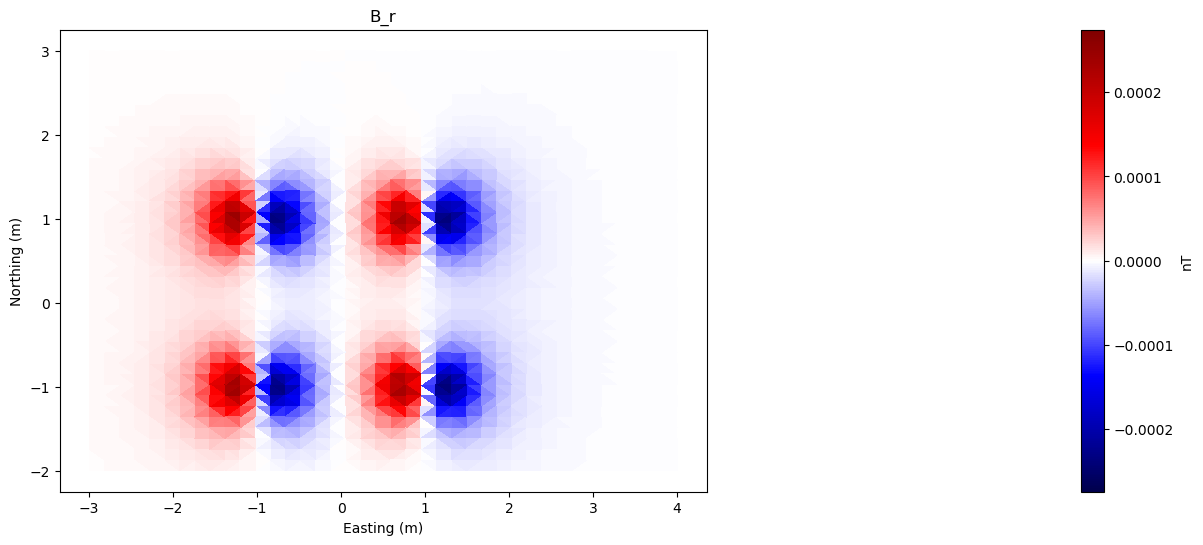

In [63]:
a, b, c = foward_modeling_spherical_coordinates(coordinates, coordinates2, 15, 45, magnetic_moments)

scale = vd.maxabs(a)
plt.figure(figsize=(20, 6))
plt.tripcolor(longitude, sph_latitude, a, cmap="seismic",  vmin=-scale, vmax=scale)
plt.colorbar(label='nT')
plt.title('B_r')
plt.xlabel('Easting (m)')
plt.ylabel('Northing (m)')
plt.axis("scaled")

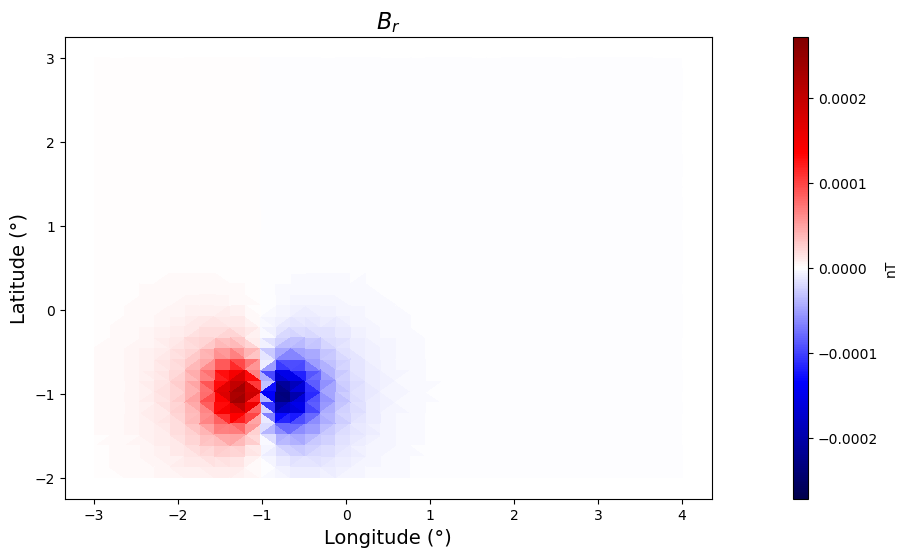

In [ ]:
# Definindo a escala simétrica
scale = vd.maxabs(a)

# Criando a figura e o eixo
fig, ax = plt.subplots(figsize=(12, 6))

# Criando o gráfico principal
im = ax.tripcolor(longitude, sph_latitude, a, cmap="seismic", vmin=-scale, vmax=scale)

# Adicionando a barra de cores
cbar = fig.colorbar(im, ax=ax, orientation='vertical', pad=0.02, aspect=30, label='nT')

# Configurando títulos e rótulos
ax.set_title('$B_r$', fontsize=16)
ax.set_xlabel('Longitude (°)', fontsize=14)
ax.set_ylabel('Latitude (°)', fontsize=14)

# Escalando o eixo
ax.axis("scaled")

# Exibindo o gráfico
plt.show()

# # Salvando a figura com alta resolução
# fig.savefig("FIG_3.png", dpi=300)

In [ ]:
B_r = np.zeros(len(coordinates[0])*len(coordinates[1]))

In [47]:
print(magnetic_moments[0].size)

2


In [43]:
for dipole in len(np.array(source_coordinates[0])):
    print(dipole)

NameError: name 'source_coordinates' is not defined